**An investigation into unsupervised machine Learning for predicting customer segment: Autoencoder method**

Customer segmentation involves uncovering information about a firm's customer base based on their interactions with the business, primarily through their purchase behavior and patterns. This practice entails separating customers into groups that reflect similarities within each cluster. By leveraging advanced unsupervised machine learning techniques, such as autoencoders, we can effectively identify distinct customer segments. This notebook explores the methodology and application of autoencoder-based clustering for customer segmentation, highlighting its advantages and potential business implications.

### Workflow Overview

1. **Load the clustering_df**: The clustering_dfset is loaded from the specified file path using the `load_clustering_df` function.
2. **clustering_df Preprocessing**: The `preprocess_clustering_df` function handles missing values, encodes categorical features, scales numerical features, and creates new features.
3. **Apply PCA**: The `apply_pca` function reduces the dimensionality of the scaled clustering_df to 3 principal components.
4. **Visualize PCA-reduced clustering_df**: The `plot_3d` function creates a 3D scatter plot of the PCA-reduced clustering_df.
5. **Build and Train Autoencoder**: The `build_autoencoder` function creates and compiles the autoencoder model, while the `train_autoencoder` function trains it on the scaled clustering_df.
6. **Encode and Cluster clustering_df**: The `encoder.predict` method encodes the clustering_df, and the `cluster_clustering_df` function applies K-means clustering to the encoded clustering_df.
7. **Evaluate Clustering Performance**: The `evaluate_clustering` function calculates the silhouette and Calinski-Harabasz scores for the clustering. The `compare_clustering_methods` function compares the autoencoder-based clustering with traditional clustering methods.
8. **Profile the Clusters**: The `profile_clusters` function visualizes and describes the characteristics of each cluster.


# Libraries & data Loading


In [ ]:
## install libraries (Do this ones )
# ! pip install yellowbrick

In [ ]:
#Importing all required libraries
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import colors
from matplotlib.colors import ListedColormap
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

from tensorflow.python.keras import Sequential
from tensorflow.keras import layers, optimizers
from tensorflow.keras.layers import *
from tensorflow.keras import Model

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.losses import mse
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Input, Dense, LeakyReLU, BatchNormalization, Dropout

from datetime import date

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import pairwise_distances_argmin_min


In [ ]:
#Reading the clustering_dfset
clustering_df = pd.read_csv('marketing_campaign.csv',sep='\t',parse_dates=['Dt_Customer'])
clustering_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
#Information on features
clustering_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

- There are missing values in income
- There are some categorical features in our dataset


# EDA

[Text(0.5, 1.0, 'Education level of Customer')]

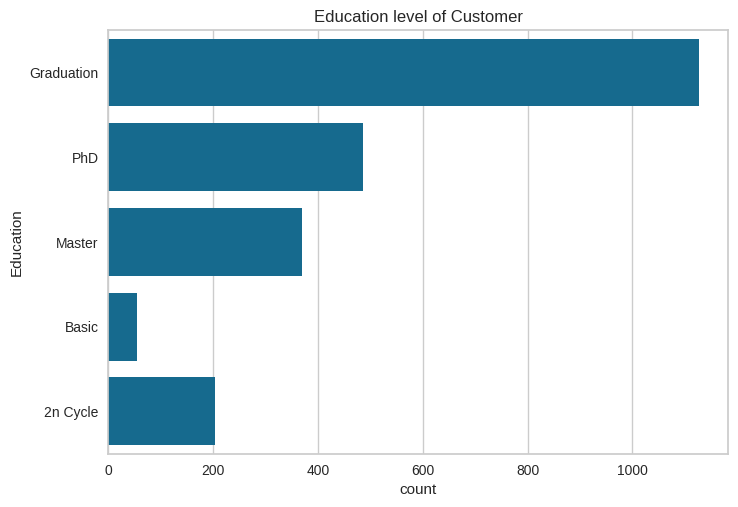

In [ ]:
sns.countplot(clustering_df.Education).set(title = "Education level of Customer")

[Text(0.5, 1.0, 'Marital Status')]

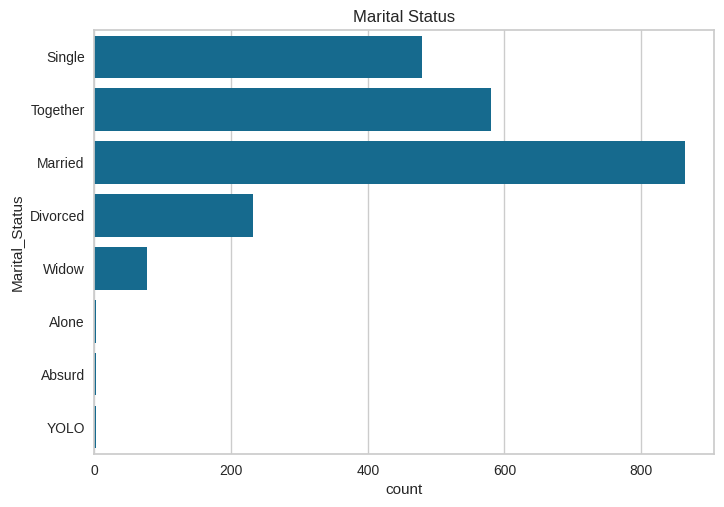

In [ ]:
sns.countplot(clustering_df.Marital_Status).set(title  = "Marital Status")

# Data Preprocessing

clustering_df preprocessing is a clustering_df mining technique which is used to transform the raw clustering_df in a useful and efficient format.

**Steps Involved in clustering_df Preprocessing:**

1. Data Cleaning
1. Data Transformation
1. Data Reduction


In [ ]:
print(clustering_df.Education.value_counts())
#Segmenting Education levels in three groups
clustering_df.Education = clustering_df.Education.replace({'PhD':'PostGraduation','Master':'PostGraduation','2n Cycle':'UnderGraduation','Basic':'UnderGraduation'})
print('-'*30)
print(clustering_df.Education.value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
------------------------------
Education
Graduation         1127
PostGraduation      856
UnderGraduation     257
Name: count, dtype: int64


In [ ]:
print(clustering_df.Marital_Status.value_counts())
# Segmenting Marital Status in two groups
clustering_df.Marital_Status = clustering_df.Marital_Status.replace({'Married':'Together','Single':'Alone','Divorced':'Alone','Widow':'Alone','Absurd':'Alone','YOLO':'Alone'})
print('-'*40)
print(clustering_df.Marital_Status.value_counts())

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
----------------------------------------
Marital_Status
Together    1444
Alone        796
Name: count, dtype: int64


<Axes: xlabel='Income'>

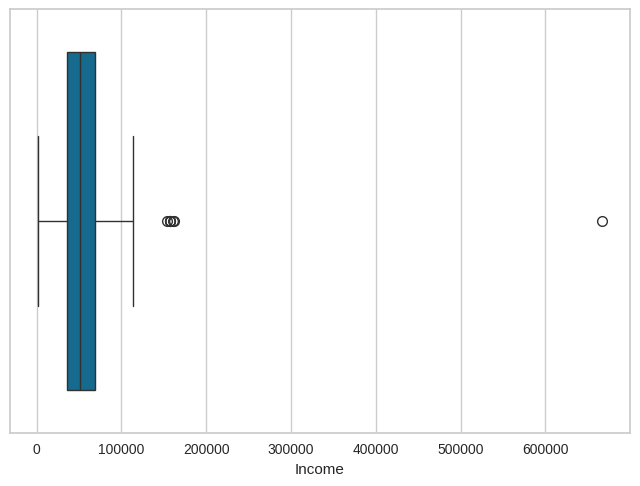

In [ ]:
# prompt: create box and wisker plot for df['inome']

import seaborn as sns

sns.boxplot(x=clustering_df['Income'])


In [ ]:
clustering_df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Alone,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Alone,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PostGraduation,Together,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Together,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PostGraduation,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Alone,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,PostGraduation,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [ ]:
# @title Data processing and feature Engineering
#Drop NA values
clustering_df.dropna(inplace=True)
#Dropping the outlier by setting a cap on income
clustering_df = clustering_df[clustering_df.Income<600000]

#New feature for total spendings on various items and Time with the company
def get_age(birthyear):
    return date.today().year - birthyear
clustering_df["Age"] = clustering_df.Year_Birth.apply(get_age)

clustering_df["Spent"] = clustering_df["MntWines"] + clustering_df["MntFruits"] +\
 clustering_df["MntMeatProducts"] + clustering_df["MntFishProducts"] +\
  clustering_df["MntSweetProducts"] + clustering_df["MntGoldProds"]

clustering_df['Time_With_Company'] = pd.to_datetime(clustering_df.Dt_Customer, dayfirst = True, format = '%d-%m-%Y')
clustering_df['Time_With_Company'] = pd.to_numeric(clustering_df.Time_With_Company.dt.date\
                                                   .apply(lambda z: (date.today() - z)).dt.days, downcast = 'integer') / 30

#New feature for total members in the householde
clustering_df['Family_Size'] = clustering_df.Kidhome + clustering_df.Teenhome + clustering_df.Marital_Status.replace({'Alone':1,'Together':2})

#Feature pertaining parenthood
clustering_df['Is_Parent'] = np.where((clustering_df.Kidhome + clustering_df.Teenhome)>0,1,0)

#Dropping some of the features
clustering_df.drop(['ID','Year_Birth','Dt_Customer','Z_CostContact','Z_Revenue'],axis=1,inplace=True)

clustering_df.head()


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spent,Time_With_Company,Family_Size,Is_Parent
0,Graduation,Alone,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,1,67,1617,144.933333,1,0
1,Graduation,Alone,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,70,27,126.600000,3,1
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,59,776,133.233333,2,0
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,40,53,127.466667,3,1
4,PostGraduation,Together,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,43,422,128.200000,3,1


In [ ]:
#Converting the labels into a numeric form so as to convert them into the machine-readable form
label_encoder = LabelEncoder()
for item in ['Education','Marital_Status']:
    clustering_df[item] = clustering_df[[item]].apply(label_encoder.fit_transform)
clustering_df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spent,Time_With_Company,Family_Size,Is_Parent
0,0,0,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,1,67,1617,144.933333,1,0
1,0,0,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,70,27,126.600000,3,1
2,0,1,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,59,776,133.233333,2,0
3,0,1,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,40,53,127.466667,3,1
4,1,1,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,43,422,128.200000,3,1


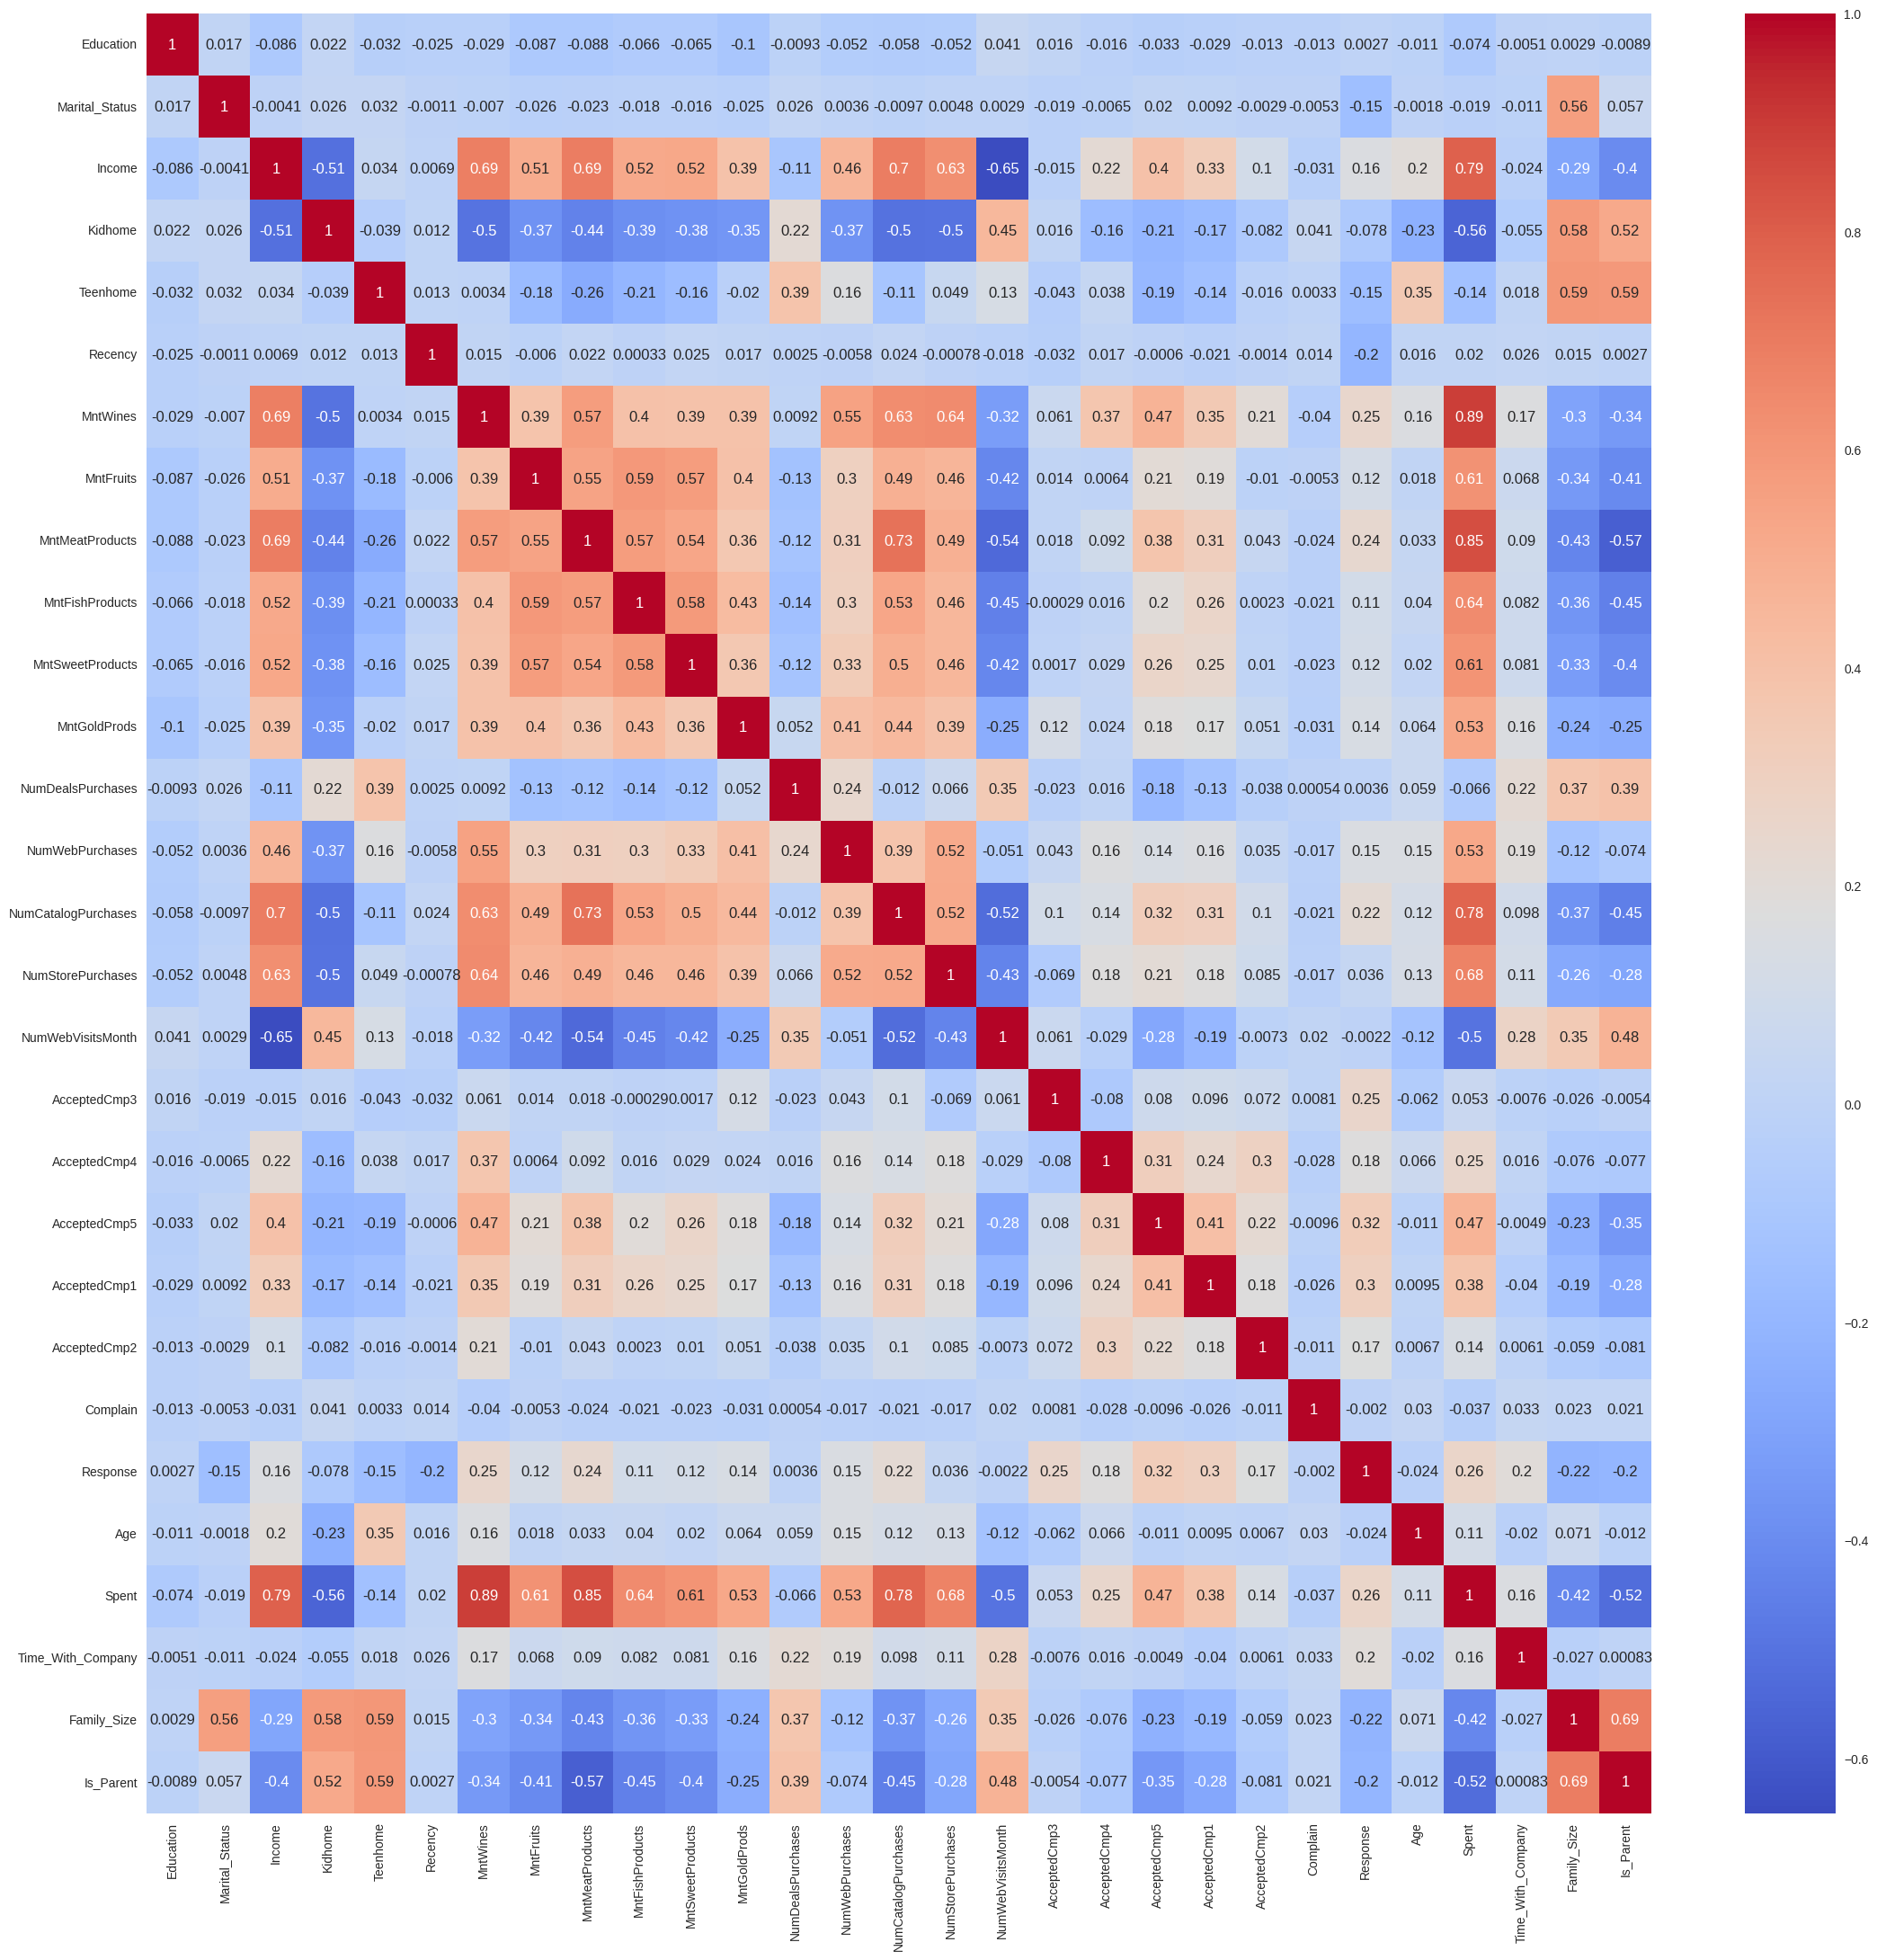

In [ ]:
# Heat map among all numerical variables
cor = clustering_df.corr()
plt.figure(figsize = (27,26))
sns.heatmap(cor, annot = True, cmap = 'coolwarm')
plt.show()

In [ ]:
#Standardizes a feature by subtracting the mean and then scaling to unit variance
scaler = StandardScaler()
scaled_clustering_df = scaler.fit_transform(clustering_df)
# scaled_clustering_df = scaled_clustering_df.copy()


# PCA

The higher the number of features, the harder it is to work with it. Many of these features are correlated, and hence redundant. This is why will be performing dimensionality reduction on the selected features before putting them through a classifier.

Dimensionality reduction is the process of reducing the number of random variables under consideration, by obtaining a set of principal variables (3 principal components).


In [ ]:
#Transformation of clustering_df
pca = PCA(n_components=3)
pca_clustering_df = pd.DataFrame(pca.fit_transform(scaled_clustering_df),columns=['pca1', 'pca2', 'pca3'])
pca_clustering_df.head()

,pca1,pca2,pca3
0,4.746037,-0.350736,0.329565
1,-2.669817,-0.313449,-0.474258
2,2.089361,-0.488971,-1.182586
3,-2.820096,-1.250915,-0.055328
4,-0.787240,0.217800,-0.734795


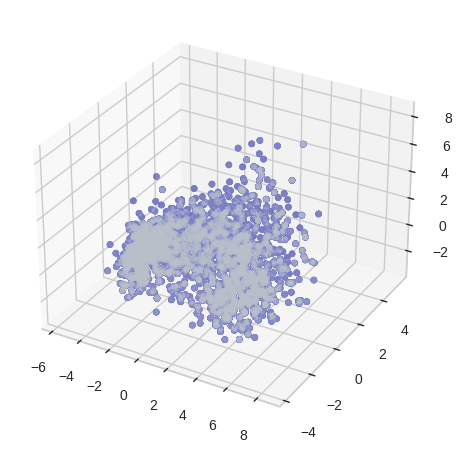

In [ ]:
#Plotting the reduced clustering_df
ax = plt.axes(projection='3d')
for color in ['black', 'blue', '#B9C0C9']:
    n = 2340
    x, y = np.random.rand(2, n)
    scale = 200.0 * np.random.rand(n)
    ax.scatter3D(pca_clustering_df['pca1'],pca_clustering_df['pca2'],pca_clustering_df['pca3'],c=color,marker='o');

## Traditional Method of Clustering

In [ ]:
# Define the range of clusters to try
# @title kmeans
def kmeans_clustering(scaled_clustering_df, k_range=range(2, 11)):
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans_labels = kmeans.fit_predict(scaled_clustering_df)
        silhouette_avg = silhouette_score(scaled_clustering_df, kmeans_labels)
        calinski_harabasz_avg = calinski_harabasz_score(scaled_clustering_df, kmeans_labels)
        print(f"K-means with {k} clusters")
        print(f"Silhouette Score: {silhouette_avg:.4f}")
        print(f"Calinski-Harabasz Index: {calinski_harabasz_avg:.4f}\n")


In [ ]:
# @title with pca  K-means Clustering
kmeans_clustering(pca_clustering_df, k_range=range(2, 11))



K-means with 2 clusters
Silhouette Score: 0.4663
Calinski-Harabasz Index: 2210.2279

K-means with 3 clusters
Silhouette Score: 0.4275
Calinski-Harabasz Index: 2073.8837

K-means with 4 clusters
Silhouette Score: 0.4268
Calinski-Harabasz Index: 1913.4799

K-means with 5 clusters
Silhouette Score: 0.3360
Calinski-Harabasz Index: 1794.6448

K-means with 6 clusters
Silhouette Score: 0.3192
Calinski-Harabasz Index: 1692.3479

K-means with 7 clusters
Silhouette Score: 0.3243
Calinski-Harabasz Index: 1595.7754

K-means with 8 clusters
Silhouette Score: 0.3086
Calinski-Harabasz Index: 1527.1956

K-means with 9 clusters
Silhouette Score: 0.3075
Calinski-Harabasz Index: 1487.5977

K-means with 10 clusters
Silhouette Score: 0.2995
Calinski-Harabasz Index: 1438.9920



In [ ]:
# @title without pca  K-means Clustering
kmeans_clustering(scaled_clustering_df, k_range=range(2, 11))

K-means with 2 clusters
Silhouette Score: 0.2494
Calinski-Harabasz Index: 631.0993

K-means with 3 clusters
Silhouette Score: 0.1766
Calinski-Harabasz Index: 459.7027

K-means with 4 clusters
Silhouette Score: 0.1740
Calinski-Harabasz Index: 365.6610

K-means with 5 clusters
Silhouette Score: 0.1795
Calinski-Harabasz Index: 313.9039

K-means with 6 clusters
Silhouette Score: 0.1105
Calinski-Harabasz Index: 283.7718

K-means with 7 clusters
Silhouette Score: 0.1375
Calinski-Harabasz Index: 260.6207

K-means with 8 clusters
Silhouette Score: 0.1211
Calinski-Harabasz Index: 249.0970

K-means with 9 clusters
Silhouette Score: 0.1024
Calinski-Harabasz Index: 229.8408

K-means with 10 clusters
Silhouette Score: 0.1054
Calinski-Harabasz Index: 204.6907



In [ ]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
import numpy as np
# @title DBSCAN
# Assume scaled_clustering_df is your scaled data
def dbscan_clustering(scaled_clustering_df, eps=8, min_samples=4):
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    model = db.fit(scaled_clustering_df)
    labels = model.labels_

    # Identify the core points
    sample_cores = np.zeros_like(labels, dtype=bool)
    sample_cores[db.core_sample_indices_] = True

    # Calculate the number of clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print('Number of clusters:', n_clusters)

    # Calculate the silhouette score
    silhouette_score_ = silhouette_score(scaled_clustering_df, labels)
    print('Silhouette Score:', silhouette_score_)

    # Calculate the Calinski-Harabasz score
    calinski_harabasz_score_ = calinski_harabasz_score(scaled_clustering_df, labels)
    print('Calinski-Harabasz Score:', calinski_harabasz_score_)


In [ ]:
# @title with pca  DBSCAN Clustering
#dbscan_clustering(pca_clustering_df, eps=8, min_samples=4)



Number of clusters: 1


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
# @title without pca  DBSCAN Clustering
dbscan_clustering(scaled_clustering_df, eps=8, min_samples=4)

Number of clusters: 3
Silhouette Score: 0.42343311669188094
Calinski-Harabasz Score: 66.91611472182913


In [ ]:
# Define the range of clusters to try
# @title Hierarchical Clustering
def hierarchical_clustering(scaled_clustering_df, k_range=range(2, 11)):
    for k in k_range:
        linked = linkage(scaled_clustering_df, 'ward')
        hierarchical_labels = fcluster(linked, k, criterion='maxclust')

        silhouette_avg = silhouette_score(scaled_clustering_df, hierarchical_labels)
        calinski_harabasz_avg = calinski_harabasz_score(scaled_clustering_df, hierarchical_labels)
        print(f"Hierarchical Clustering with {k} clusters")
        print(f"Silhouette Score: {silhouette_avg:.4f}")
        print(f"Calinski-Harabasz Index: {calinski_harabasz_avg:.4f}\n")


In [ ]:
# @title without pca Hierarchical Clustering
hierarchical_clustering(pca_clustering_df, k_range=range(2, 11))

Hierarchical Clustering with 2 clusters
Silhouette Score: 0.4434
Calinski-Harabasz Index: 2023.7131

Hierarchical Clustering with 3 clusters
Silhouette Score: 0.4198
Calinski-Harabasz Index: 1918.6831

Hierarchical Clustering with 4 clusters
Silhouette Score: 0.4253
Calinski-Harabasz Index: 1680.6086

Hierarchical Clustering with 5 clusters
Silhouette Score: 0.3179
Calinski-Harabasz Index: 1651.1162

Hierarchical Clustering with 6 clusters
Silhouette Score: 0.2880
Calinski-Harabasz Index: 1502.3974

Hierarchical Clustering with 7 clusters
Silhouette Score: 0.2769
Calinski-Harabasz Index: 1393.6551

Hierarchical Clustering with 8 clusters
Silhouette Score: 0.2558
Calinski-Harabasz Index: 1318.4721

Hierarchical Clustering with 9 clusters
Silhouette Score: 0.2376
Calinski-Harabasz Index: 1268.9146

Hierarchical Clustering with 10 clusters
Silhouette Score: 0.2366
Calinski-Harabasz Index: 1229.2461



In [ ]:
# @title without pca Hierarchical Clustering
hierarchical_clustering(scaled_clustering_df, k_range=range(2, 11))

Hierarchical Clustering with 2 clusters
Silhouette Score: 0.2740
Calinski-Harabasz Index: 481.6075

Hierarchical Clustering with 3 clusters
Silhouette Score: 0.1420
Calinski-Harabasz Index: 374.6278

Hierarchical Clustering with 4 clusters
Silhouette Score: 0.1529
Calinski-Harabasz Index: 305.1506

Hierarchical Clustering with 5 clusters
Silhouette Score: 0.1639
Calinski-Harabasz Index: 269.4784

Hierarchical Clustering with 6 clusters
Silhouette Score: 0.1743
Calinski-Harabasz Index: 250.5139

Hierarchical Clustering with 7 clusters
Silhouette Score: 0.1755
Calinski-Harabasz Index: 235.3363

Hierarchical Clustering with 8 clusters
Silhouette Score: 0.0983
Calinski-Harabasz Index: 224.4785

Hierarchical Clustering with 9 clusters
Silhouette Score: 0.0918
Calinski-Harabasz Index: 211.8126

Hierarchical Clustering with 10 clusters
Silhouette Score: 0.1000
Calinski-Harabasz Index: 202.4402



In [ ]:
# @title Autoencoder model
def build_autoencoder_hyper(input_dim, encoding_dim):
    input_layer = Input(shape=(input_dim,))

    # Encoder
    encoder = Dense(encoding_dim, activation=None)(input_layer)
    encoder = LeakyReLU(alpha=0.1)(encoder)
    encoder = BatchNormalization()(encoder)
    encoder = Dropout(0.2)(encoder)

    bottleneck = Dense(encoding_dim // 2, activation=None)(encoder)
    bottleneck = LeakyReLU(alpha=0.1)(bottleneck)
    bottleneck = BatchNormalization()(bottleneck)
    bottleneck = Dropout(0.2)(bottleneck)

    # Decoder
    decoder = Dense(encoding_dim, activation=None)(bottleneck)
    decoder = LeakyReLU(alpha=0.1)(decoder)
    decoder = BatchNormalization()(decoder)
    decoder = Dropout(0.2)(decoder)

    output_layer = Dense(input_dim, activation='sigmoid')(decoder)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    # Encoder model to extract latent representations
    encoder_model = Model(inputs=input_layer, outputs=bottleneck)

    return autoencoder, encoder_model

In [ ]:
def build_autoencoder(input_shape):
    """
    Build and compile the autoencoder model.

    Args:
    input_shape (int): The number of input features.

    Returns:
    Model: Compiled autoencoder model.
    Model: Encoder model.
    """
    input_df = Input(shape=(input_shape,))
    x = Dense(500, activation='relu')(input_df)
    x = Dense(500, activation='relu')(x)
    x = Dense(2000, activation='relu')(x)

    encoded = Dense(2000, activation='relu')(x)
    x = Dense(500, activation='relu')(encoded)
    x = Dense(500, activation='relu')(x)
    decoded = Dense(input_shape)(x)

    autoencoder = Model(input_df, decoded)
    autoencoder.compile(optimizer='adam', loss='mean_squared_error')

    encoder = Model(input_df, encoded)

    return autoencoder, encoder

In [ ]:
# Variational Autoencoder model
# @title Variational Autoencoder (VAE) Model

def build_vae(input_dim, encoding_dim):
    input_layer = Input(shape=(input_dim,))
    h = Dense(500, activation='relu')(input_layer)
    z_mean = Dense(500 // 2)(h)
    z_log_var = Dense(500 // 2)(h)

    def sampling(args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.keras.backend.exp(0.5 * z_log_var) * epsilon

    z = Lambda(sampling, output_shape=(500 // 2,))([z_mean, z_log_var])

    decoder_h = Dense(500, activation='relu')
    decoder_mean = Dense(input_dim, activation='sigmoid')
    h_decoded = decoder_h(z)
    x_decoded_mean = decoder_mean(h_decoded)

    vae = Model(input_layer, x_decoded_mean)

    def vae_loss(input_layer, x_decoded_mean):
        xent_loss = mse(input_layer, x_decoded_mean)
        kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
        return xent_loss + kl_loss

    vae.add_loss(vae_loss(input_layer, x_decoded_mean))
    vae.compile(optimizer='adam')
    return vae, Model(inputs=input_layer, outputs=z)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras import backend as K


def build_vae_hyper(input_dim, encoding_dim):
    input_layer = Input(shape=(input_dim,))

    # Encoder
    h = Dense(encoding_dim, activation=None)(input_layer)
    h = LeakyReLU(alpha=0.1)(h)
    h = BatchNormalization()(h)
    h = Dropout(0.2)(h)

    z_mean = Dense(encoding_dim // 2)(h)
    z_log_var = Dense(encoding_dim // 2)(h)

    def sampling(args):
        z_mean, z_log_var = args
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.keras.backend.exp(0.5 * z_log_var) * epsilon

    z = Lambda(sampling, output_shape=(encoding_dim // 2,))([z_mean, z_log_var])

    # Decoder
    decoder_h = Dense(encoding_dim, activation=None)
    decoder_h_output = decoder_h(z)
    decoder_h_output = LeakyReLU(alpha=0.1)(decoder_h_output)
    decoder_h_output = BatchNormalization()(decoder_h_output)
    decoder_h_output = Dropout(0.2)(decoder_h_output)

    decoder_mean = Dense(input_dim, activation='sigmoid')
    x_decoded_mean = decoder_mean(decoder_h_output)

    vae = Model(input_layer, x_decoded_mean)

    def vae_loss(input_layer, x_decoded_mean):
        xent_loss = mse(input_layer, x_decoded_mean)
        kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
        return K.mean(xent_loss + kl_loss)

    vae.add_loss(vae_loss(input_layer, x_decoded_mean))
    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

    # Encoder model to extract latent representations
    encoder_model = Model(inputs=input_layer, outputs=z_mean)

    return vae, encoder_model


In [ ]:
# Function to apply PCA
def apply_pca(data, n_components):
    pca = PCA(n_components=n_components)
    return pca.fit_transform(data)

In [ ]:
# Function to perform clustering and evaluate
def evaluate_clustering(data, n_clusters=3):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(data)
    silhouette = silhouette_score(data, labels)
    calinski = calinski_harabasz_score(data, labels)
    return silhouette, calinski, labels

In [ ]:
# Hyperparameter tuning function
def hyperparameter_tuning(train_data, test_data, data_scaled, model_type='autoencoder'):
    params = {
        'encoding_dim': [32, 64, 128],
        'batch_size': [128, 256],
        'epochs': [30, 50, 80]
    }

    results = []
    best_params = None
    best_score = -np.inf

    for enc_dim in params['encoding_dim']:
        for batch in params['batch_size']:
            for epoch in params['epochs']:
                if model_type == 'autoencoder':
                    model, encoder_model = build_autoencoder_hyper(train_data.shape[1], enc_dim)
                else:
                    model, encoder_model = build_vae_hyper(train_data.shape[1], enc_dim)

                model.fit(train_data, train_data, epochs=epoch, batch_size=batch, shuffle=True, validation_data=(test_data, test_data))
                encoded_data = encoder_model.predict(data_scaled)
                score = evaluate_clustering(encoded_data)[0]  # Using silhouette score for simplicity

                results.append((enc_dim, batch, epoch, score))

                if score > best_score:
                    best_score = score
                    best_params = (enc_dim, batch, epoch)

    return best_params, best_score, results

In [ ]:
# Function to plot clusters
def plot_clusters(data, labels, title):
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for label in unique_labels:
        plt.scatter(data[labels == label, 0], data[labels == label, 1], label=f'Cluster {label}')
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
# Function to plot evaluation metrics
def plot_evaluation_metrics(results):
    methods = list(results.keys())
    silhouette_scores = [results[method][0] for method in methods]
    calinski_scores = [results[method][1] for method in methods]

    x = np.arange(len(methods))

    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Method')
    ax1.set_ylabel('Silhouette Score', color='tab:blue')
    ax1.bar(x - 0.2, silhouette_scores, 0.4, label='Silhouette Score', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Calinski-Harabasz Index', color='tab:red')
    ax2.bar(x + 0.2, calinski_scores, 0.4, label='Calinski-Harabasz Index', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    fig.tight_layout()
    plt.xticks(x, methods)
    plt.title('Clustering Evaluation Metrics')
    plt.show()

In [ ]:
# Function to plot hyperparameter tuning results
def plot_hyperparameter_tuning(results, model_type):
    encoding_dims, batch_sizes, epochs, scores = zip(*results)

    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(encoding_dims, batch_sizes, c=scores, cmap='viridis', s=100)
    ax.set_xlabel('Encoding Dimensions')
    ax.set_ylabel('Batch Sizes')
    ax.set_title(f'Hyperparameter Tuning for {model_type.capitalize()} (Color: Silhouette Score)')
    plt.colorbar(sc, label='Silhouette Score')
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(encoding_dims, epochs, c=scores, cmap='viridis', s=100)
    ax.set_xlabel('Encoding Dimensions')
    ax.set_ylabel('Epochs')
    ax.set_title(f'Hyperparameter Tuning for {model_type.capitalize()} (Color: Silhouette Score)')
    plt.colorbar(sc, label='Silhouette Score')
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
data_scaled = scaled_clustering_df
train_data, test_data = train_test_split(data_scaled, test_size=0.2, random_state=42)
input_dim = train_data.shape[1]
encoding_dim = 64

In [ ]:
# Traditional Autoencoder
autoencoder, encoder_model = build_autoencoder(input_dim)
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 29)]              0         
                                                                 
 dense (Dense)               (None, 500)               15000     
                                                                 
 dense_1 (Dense)             (None, 500)               250500    
                                                                 
 dense_2 (Dense)             (None, 2000)              1002000   
                                                                 
 dense_3 (Dense)             (None, 2000)              4002000   
                                                                 
 dense_4 (Dense)             (None, 500)               1000500   
                                                                 
 dense_5 (Dense)             (None, 500)               250500

Epoch 1/100
7/7 [==============================] - 5s 57ms/step - loss: 0.8236 - val_loss: 0.6013
Epoch 2/100
7/7 [==============================] - 0s 22ms/step - loss: 0.4775 - val_loss: 0.3476
Epoch 3/100
7/7 [==============================] - 0s 22ms/step - loss: 0.2748 - val_loss: 0.2111
Epoch 4/100
7/7 [==============================] - 0s 18ms/step - loss: 0.1660 - val_loss: 0.1357
Epoch 5/100
7/7 [==============================] - 0s 14ms/step - loss: 0.1031 - val_loss: 0.0904
Epoch 6/100
7/7 [==============================] - 0s 14ms/step - loss: 0.0676 - val_loss: 0.0676
Epoch 7/100
7/7 [==============================] - 0s 14ms/step - loss: 0.0477 - val_loss: 0.0497
Epoch 8/100
7/7 [==============================] - 0s 12ms/step - loss: 0.0339 - val_loss: 0.0396
Epoch 9/100
7/7 [==============================] - 0s 12ms/step - loss: 0.0249 - val_loss: 0.0318
Epoch 10/100
7/7 [==============================] - 0s 11ms/step - loss: 0.0195 - val_loss: 0.0254
Epoch 11/100
7/7 [=

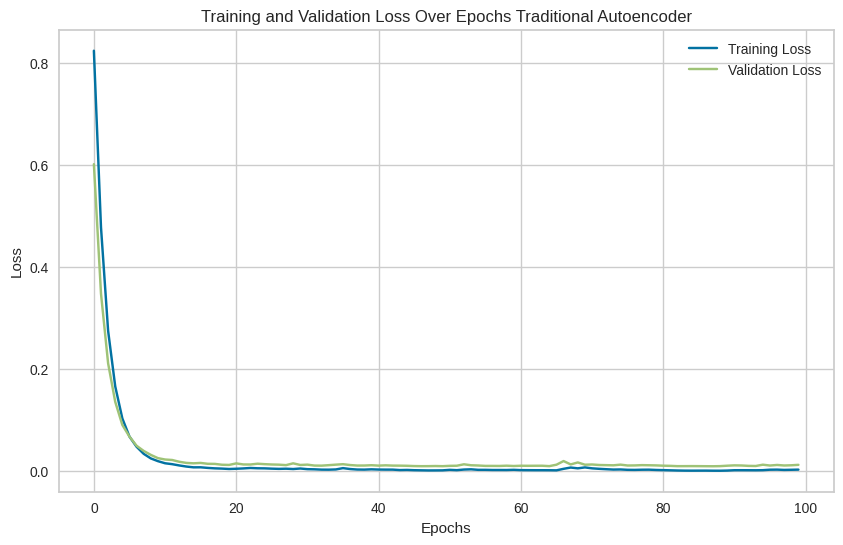

70/70 [==============================] - 0s 2ms/step


In [ ]:
# Train the model and store the history
history_autoencoder = autoencoder.fit(train_data, train_data, epochs=100, batch_size=256, shuffle=True, validation_data=(test_data, test_data))

# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_autoencoder.history['loss'], label='Training Loss')
plt.plot(history_autoencoder.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss Over Epochs Traditional Autoencoder')
plt.show()

# Encode the data
encoded_data = encoder_model.predict(data_scaled)

In [ ]:
# autoencoder.fit(train_data, train_data, epochs=100, batch_size=256, shuffle=True, validation_data=(test_data, test_data))
# encoded_data = encoder_model.predict(data_scaled)

In [ ]:
# Variational Autoencoder
vae, vae_encoder_model = build_vae(input_dim, encoding_dim)
vae.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 29)]                 0         []                            
                                                                                                  
 dense_7 (Dense)             (None, 500)                  15000     ['input_2[0][0]']             
                                                                                                  
 dense_8 (Dense)             (None, 250)                  125250    ['dense_7[0][0]']             
                                                                                                  
 dense_9 (Dense)             (None, 250)                  125250    ['dense_7[0][0]']             
                                                                                            

Epoch 1/100
7/7 [==============================] - 2s 42ms/step - loss: 9.0040 - val_loss: 5.4449
Epoch 2/100
7/7 [==============================] - 0s 13ms/step - loss: 4.5320 - val_loss: 3.4722
Epoch 3/100
7/7 [==============================] - 0s 13ms/step - loss: 3.0075 - val_loss: 2.6108
Epoch 4/100
7/7 [==============================] - 0s 13ms/step - loss: 2.3587 - val_loss: 2.1860
Epoch 5/100
7/7 [==============================] - 0s 13ms/step - loss: 2.0218 - val_loss: 1.9353
Epoch 6/100
7/7 [==============================] - 0s 15ms/step - loss: 1.8163 - val_loss: 1.7721
Epoch 7/100
7/7 [==============================] - 0s 20ms/step - loss: 1.6797 - val_loss: 1.6617
Epoch 8/100
7/7 [==============================] - 0s 14ms/step - loss: 1.5833 - val_loss: 1.5785
Epoch 9/100
7/7 [==============================] - 0s 12ms/step - loss: 1.5112 - val_loss: 1.5149
Epoch 10/100
7/7 [==============================] - 0s 14ms/step - loss: 1.4550 - val_loss: 1.4628
Epoch 11/100
7/7 [=

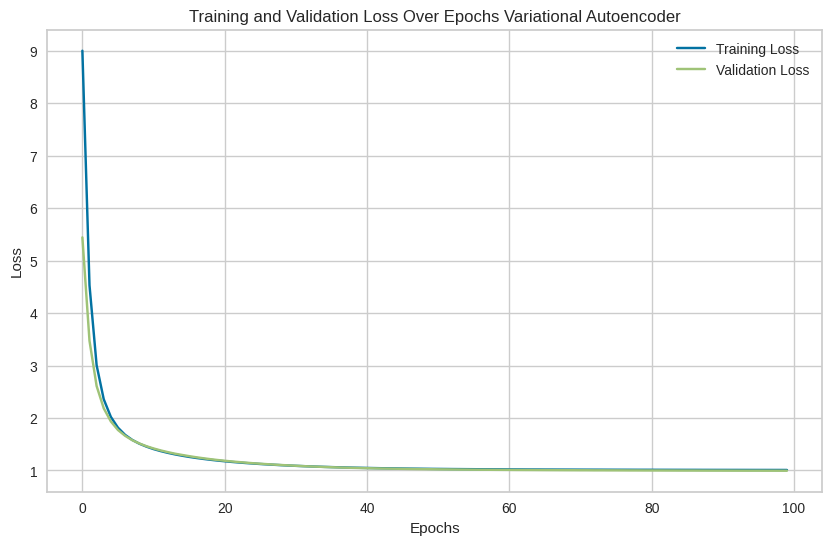

70/70 [==============================] - 0s 1ms/step


In [ ]:
history_vae= vae.fit(train_data, train_data, epochs=100, batch_size=256, shuffle=True, validation_data=(test_data, test_data))

# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_vae.history['loss'], label='Training Loss')
plt.plot(history_vae.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss Over Epochs Variational Autoencoder')
plt.show()

encoded_vae_data = vae_encoder_model.predict(data_scaled)

In [ ]:
# Apply PCA
pca_data = apply_pca(data_scaled, n_components=2)
pca_encoded_data = apply_pca(encoded_data, n_components=2)
pca_encoded_vae_data = apply_pca(encoded_vae_data, n_components=2)

In [ ]:
# pca_encoded_vae_data, encoded_vae_data, pca_encoded_data, encoded_data

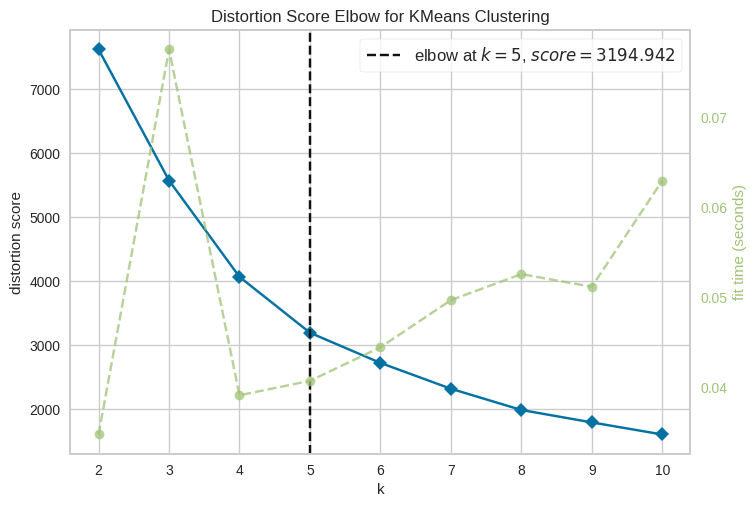

In [ ]:
#Elbow method to find numbers of clusters to make
elbow = KElbowVisualizer(KMeans(), k=10)
elbow.fit(pca_encoded_data)
elbow.show();

So the number of clusters is four (4)

In [ ]:
# Evaluate clustering
results = {}
results['Autoencoder'] = evaluate_clustering(encoded_data, n_clusters=4)
results['Autoencoder PCA'] = evaluate_clustering(pca_encoded_data, n_clusters=4)
results['VAE'] = evaluate_clustering(encoded_vae_data, n_clusters=4)
results['VAE PCA'] = evaluate_clustering(pca_encoded_vae_data, n_clusters=4)

In [ ]:
# Extracting the Silhouette Scores and Calinski-Harabasz Index
extracted_results = {method: (values[0], values[1]) for method, values in results.items()}

# Create a DataFrame from the results dictionary
df_results = pd.DataFrame.from_dict(extracted_results, orient='index', columns=['Silhouette Score', 'Calinski-Harabasz Index'])
df_results

,Silhouette Score,Calinski-Harabasz Index
Autoencoder,0.115411,227.226779
Autoencoder PCA,0.463081,2401.509030
VAE,0.003617,7.905990
VAE PCA,0.311498,1304.734083


In [ ]:
results

{'Autoencoder': (0.115410596,
  227.2267788174182,
  array([0, 1, 0, ..., 0, 3, 1], dtype=int32)),
 'Autoencoder PCA': (0.46308053,
  2401.5090295296072,
  array([3, 0, 1, ..., 1, 1, 2], dtype=int32)),
 'VAE': (0.0036171575,
  7.905989874860308,
  array([2, 1, 2, ..., 1, 2, 3], dtype=int32)),
 'VAE PCA': (0.3114982,
  1304.7340825647088,
  array([1, 0, 1, ..., 2, 0, 1], dtype=int32))}

In [ ]:
results['Autoencoder'][2]

array([0, 1, 0, ..., 0, 3, 1], dtype=int32)

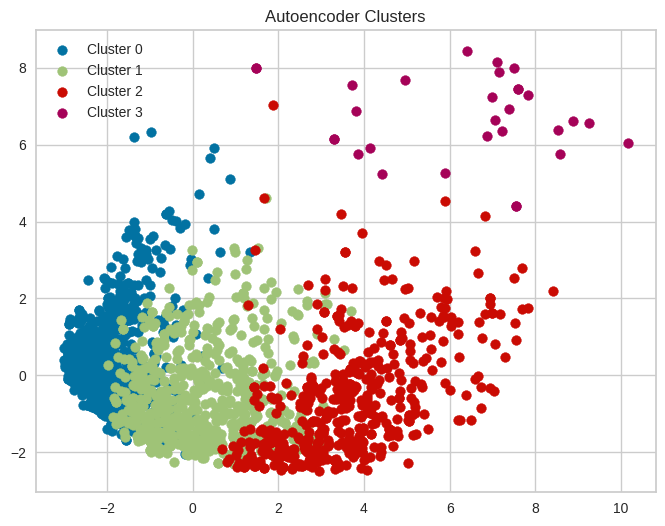

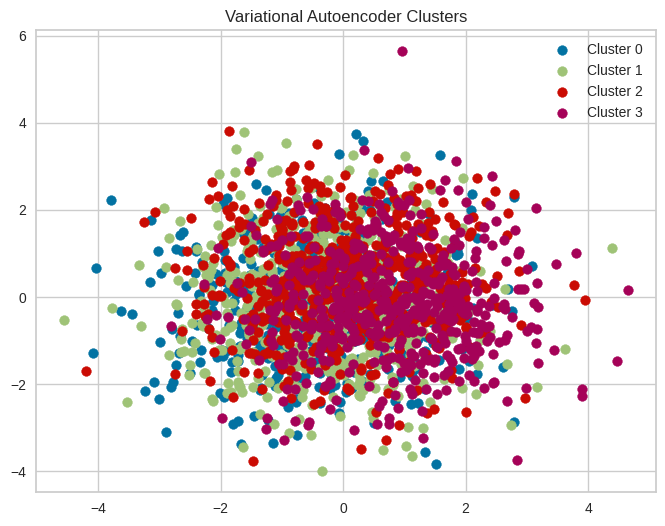

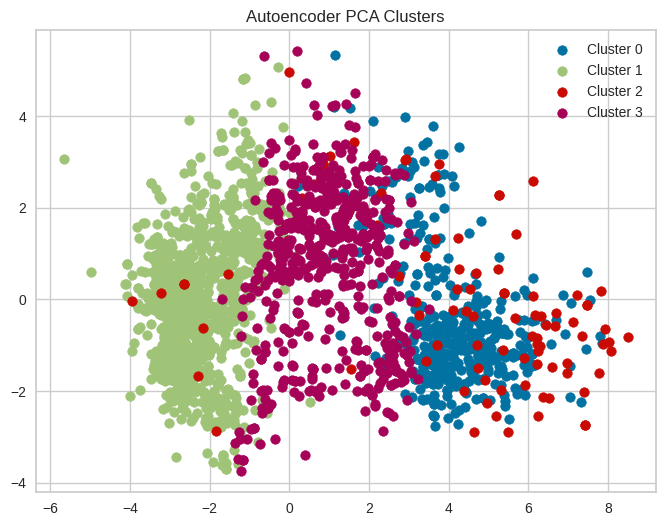

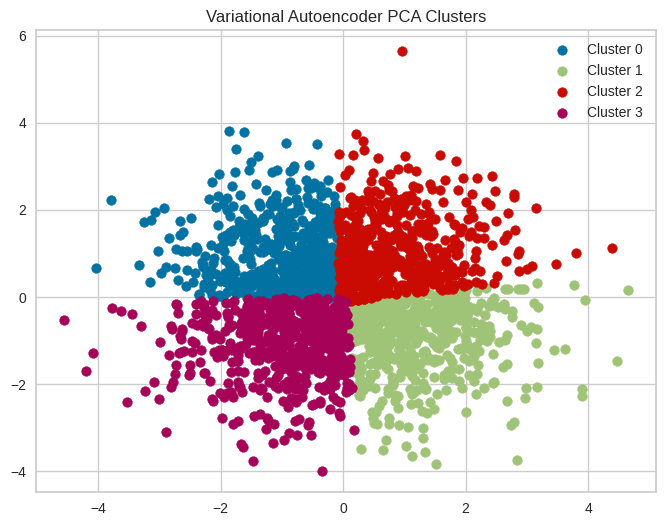

In [ ]:
# Plot clusters
plot_clusters(pca_encoded_data, results['Autoencoder'][2], 'Autoencoder Clusters')
plot_clusters(pca_encoded_vae_data, results['VAE'][2], 'Variational Autoencoder Clusters')
plot_clusters(pca_data, results['Autoencoder PCA'][2], 'Autoencoder PCA Clusters')
plot_clusters(pca_encoded_vae_data, results['VAE PCA'][2], 'Variational Autoencoder PCA Clusters')

In [ ]:
pca_clustering_df

,pca1,pca2,pca3
0,4.746037,-0.350736,0.329565
1,-2.669817,-0.313449,-0.474258
2,2.089361,-0.488971,-1.182586
3,-2.820096,-1.250915,-0.055328
4,-0.787240,0.217800,-0.734795
...,...,...,...
2210,2.242893,2.285147,-1.137330
2211,-1.802164,3.209955,1.065282
2212,2.432868,-1.254443,0.828815
2213,1.382032,1.518584,-1.441948


In [ ]:
kmeans = KMeans(4)
kmeans.fit(pca_encoded_data)
labels = kmeans.labels_
y = kmeans.fit_predict(pca_encoded_data)
pca_clustering_df['Cluster'] = y
#Adding the cluster to original clustering_dfset
clustering_df['Cluster'] = y

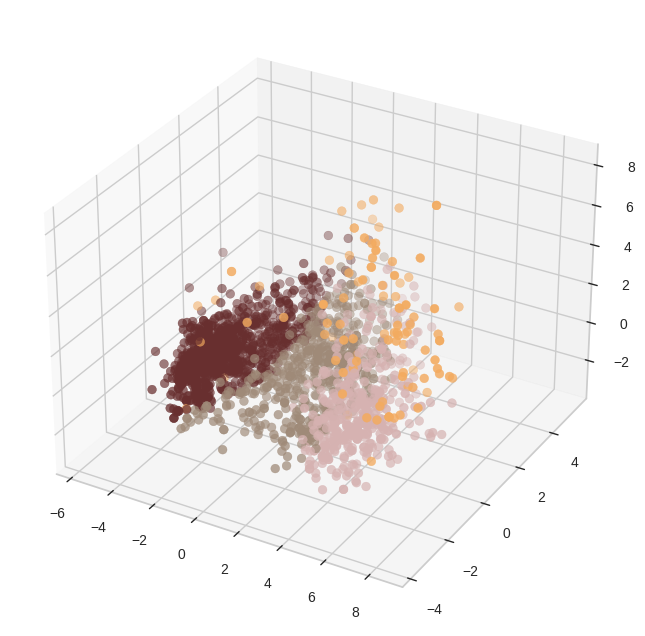

In [ ]:
#3-D distribution of the clusters
plt.figure(figsize=(10,8))
ax = plt.axes(projection='3d')
ax.scatter3D(pca_clustering_df['pca1'],pca_clustering_df['pca2'],pca_clustering_df['pca3'],c=pca_clustering_df['Cluster'],cmap=cmap,marker='o',s=40);

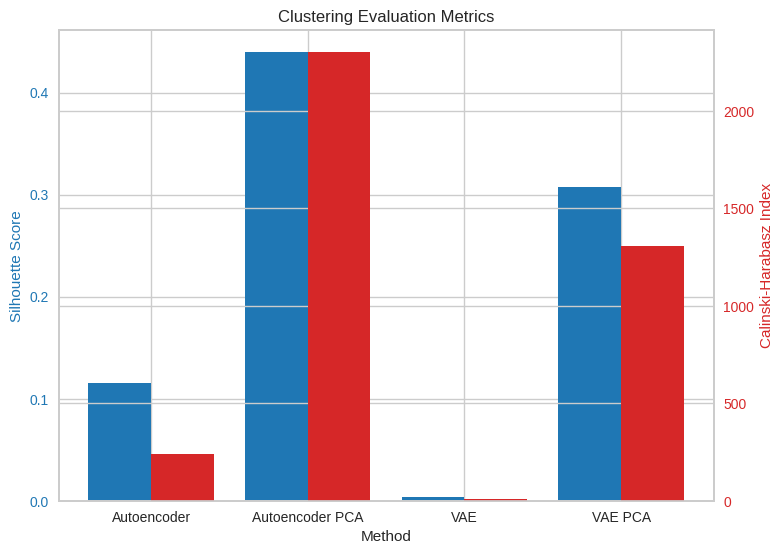

In [ ]:
# Plot evaluation metrics
plot_evaluation_metrics(results)

In [ ]:
# @title Hyperparameter tuning
best_params_ae, best_score_ae, tuning_results_ae = hyperparameter_tuning(train_data, test_data, data_scaled, 'autoencoder')
best_params_vae, best_score_vae, tuning_results_vae = hyperparameter_tuning(train_data, test_data, data_scaled, 'vae')


Epoch 1/30
14/14 [==============================] - 4s 20ms/step - loss: 1.2656 - val_loss: 1.2251
Epoch 2/30
14/14 [==============================] - 0s 7ms/step - loss: 1.2051 - val_loss: 1.1917
Epoch 3/30
14/14 [==============================] - 0s 9ms/step - loss: 1.1538 - val_loss: 1.1512
Epoch 4/30
14/14 [==============================] - 0s 9ms/step - loss: 1.1059 - val_loss: 1.1048
Epoch 5/30
14/14 [==============================] - 0s 7ms/step - loss: 1.0630 - val_loss: 1.0570
Epoch 6/30
14/14 [==============================] - 0s 7ms/step - loss: 1.0269 - val_loss: 1.0138
Epoch 7/30
14/14 [==============================] - 0s 7ms/step - loss: 0.9963 - val_loss: 0.9772
Epoch 8/30
14/14 [==============================] - 0s 9ms/step - loss: 0.9709 - val_loss: 0.9470
Epoch 9/30
14/14 [==============================] - 0s 10ms/step - loss: 0.9509 - val_loss: 0.9209
Epoch 10/30
14/14 [==============================] - 0s 11ms/step - loss: 0.9328 - val_loss: 0.8990
Epoch 11/30
14/1

In [ ]:
print("Best Parameters for Autoencoder:", best_params_ae)
print("Best Silhouette Score for Autoencoder:", best_score_ae)
print("Best Parameters for VAE:", best_params_vae)
print("Best Silhouette Score for VAE:", best_score_vae)

Best Parameters for Autoencoder: (32, 256, 30)
Best Silhouette Score for Autoencoder: 0.3284232
Best Parameters for VAE: (128, 128, 80)
Best Silhouette Score for VAE: 0.14618598


In [ ]:
# Traditional Autoencoder
autoencoder_hyper, encoder_model_hyper = build_autoencoder_hyper(input_dim, 32)
autoencoder_hyper.fit(train_data, train_data, epochs=50, batch_size=256, shuffle=True, validation_data=(test_data, test_data))
encoded_data_hyper = encoder_model_hyper.predict(data_scaled)

Epoch 1/50
7/7 [==============================] - 2s 37ms/step - loss: 1.2698 - val_loss: 1.2259
Epoch 2/50
7/7 [==============================] - 0s 9ms/step - loss: 1.2331 - val_loss: 1.2119
Epoch 3/50
7/7 [==============================] - 0s 9ms/step - loss: 1.2088 - val_loss: 1.1963
Epoch 4/50
7/7 [==============================] - 0s 9ms/step - loss: 1.1782 - val_loss: 1.1781
Epoch 5/50
7/7 [==============================] - 0s 9ms/step - loss: 1.1491 - val_loss: 1.1578
Epoch 6/50
7/7 [==============================] - 0s 9ms/step - loss: 1.1244 - val_loss: 1.1364
Epoch 7/50
7/7 [==============================] - 0s 9ms/step - loss: 1.1013 - val_loss: 1.1141
Epoch 8/50
7/7 [==============================] - 0s 10ms/step - loss: 1.0779 - val_loss: 1.0914
Epoch 9/50
7/7 [==============================] - 0s 11ms/step - loss: 1.0545 - val_loss: 1.0691
Epoch 10/50
7/7 [==============================] - 0s 12ms/step - loss: 1.0331 - val_loss: 1.0474
Epoch 11/50
7/7 [==================

In [ ]:
# Variational Autoencoder
vae_hyper, vae_encoder_model_hyper = build_vae_hyper(input_dim, 32)
vae_hyper.fit(train_data, train_data, epochs=80, batch_size=128, shuffle=True, validation_data=(test_data, test_data))
encoded_vae_data_hyper = vae_encoder_model_hyper.predict(data_scaled)

Epoch 1/80
14/14 [==============================] - 3s 29ms/step - loss: 80.7328 - val_loss: 9.7407
Epoch 2/80
14/14 [==============================] - 0s 11ms/step - loss: 21.9656 - val_loss: 8.5982
Epoch 3/80
14/14 [==============================] - 0s 12ms/step - loss: 18.2681 - val_loss: 7.9669
Epoch 4/80
14/14 [==============================] - 0s 13ms/step - loss: 14.6565 - val_loss: 7.6483
Epoch 5/80
14/14 [==============================] - 0s 10ms/step - loss: 13.8471 - val_loss: 7.4874
Epoch 6/80
14/14 [==============================] - 0s 12ms/step - loss: 12.1256 - val_loss: 7.4250
Epoch 7/80
14/14 [==============================] - 0s 12ms/step - loss: 14.0246 - val_loss: 7.1850
Epoch 8/80
14/14 [==============================] - 0s 11ms/step - loss: 12.2311 - val_loss: 7.0492
Epoch 9/80
14/14 [==============================] - 0s 10ms/step - loss: 10.3037 - val_loss: 6.7888
Epoch 10/80
14/14 [==============================] - 0s 12ms/step - loss: 9.4052 - val_loss: 6.6793


In [ ]:
# Apply PCA
pca_data_hyper = apply_pca(data_scaled, n_components=2)
pca_encoded_data_hyper = apply_pca(encoded_data_hyper, n_components=2)
pca_encoded_vae_data_hyper = apply_pca(encoded_vae_data_hyper, n_components=2)

In [ ]:
# Evaluate clustering
results_hyper = {}
results_hyper['Autoencoder'] = evaluate_clustering(encoded_data_hyper)
results_hyper['Autoencoder PCA'] = evaluate_clustering(pca_encoded_data_hyper)
results_hyper['VAE'] = evaluate_clustering(encoded_vae_data_hyper)
results_hyper['VAE PCA'] = evaluate_clustering(pca_encoded_vae_data_hyper)

# Plot clusters
plot_clusters(pca_encoded_data_hyper, results['Autoencoder'][2], 'Autoencoder Clusters Hyperparameter')
plot_clusters(pca_encoded_vae_data_hyper, results['VAE'][2], 'Variational Autoencoder Clusters Hyperparameter')
plot_clusters(pca_data_hyper, results['Autoencoder PCA'][2], 'Autoencoder PCA Clusters Hyperparameter')
plot_clusters(pca_encoded_vae_data_hyper, results['VAE PCA'][2], 'Variational Autoencoder PCA Clusters Hyperparameter')

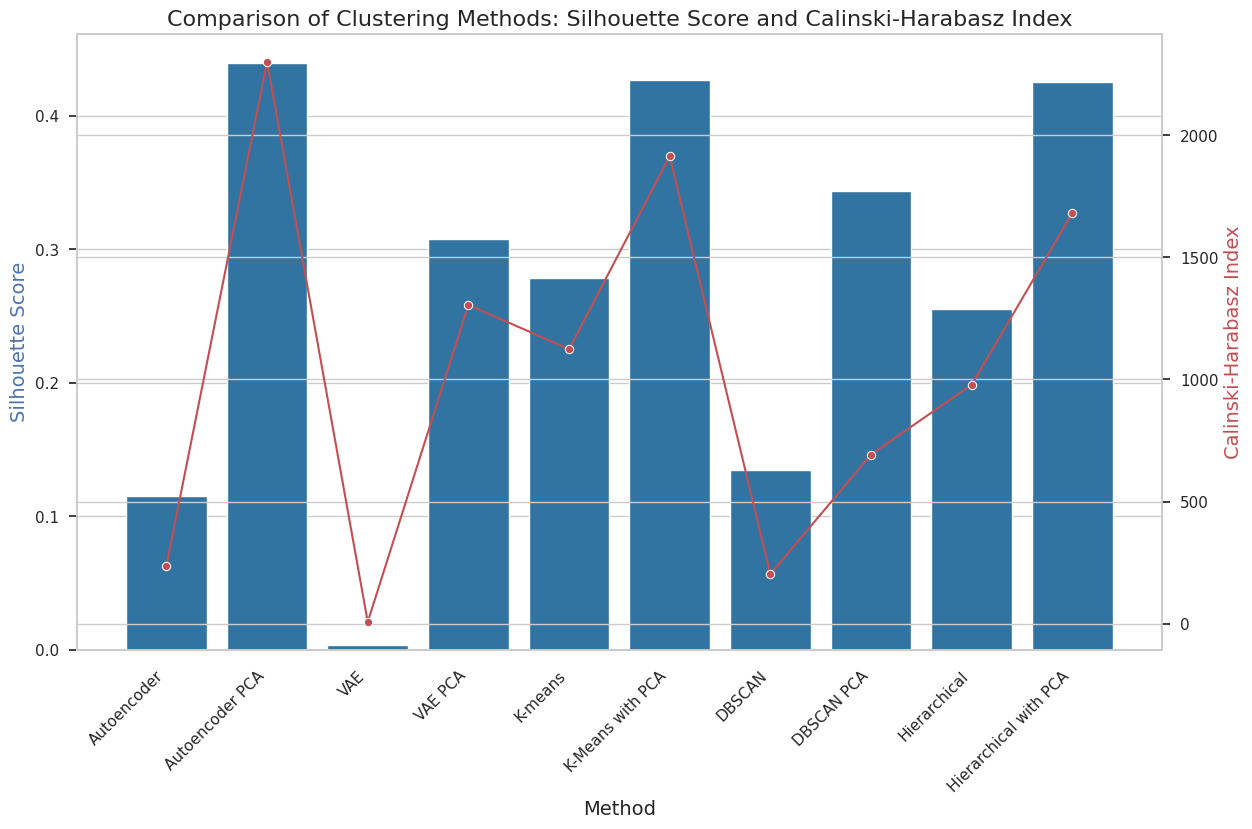

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Updated data
data = {
    'Method': ['Autoencoder', 'Autoencoder PCA', 'VAE', 'VAE PCA', 'K-means', 'K-Means with PCA', 'DBSCAN', 'DBSCAN PCA', 'Hierarchical', 'Hierarchical with PCA'],
    'Silhouette Score': [0.115328, 0.439293, 0.003647, 0.307383, 0.278314, 0.4268, 0.134897, 0.34334, 0.255103, 0.4253],
    'Calinski-Harabasz Index': [238.210063, 2299.436458, 8.008472, 1305.442805, 1123.890273, 1913.4799, 203.678912, 692.4556, 978.564782, 1680.6086]
}

# Create DataFrame
df = pd.DataFrame(data)

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 8))

sns.set(style="whitegrid")
sns.set_palette("tab10")

# Silhouette Score barplot
sns.barplot(x='Method', y='Silhouette Score', data=df, ax=ax1)

# Create a second y-axis
ax2 = ax1.twinx()

# Calinski-Harabasz Index lineplot
sns.lineplot(x='Method', y='Calinski-Harabasz Index', data=df, ax=ax2, color='r', marker='o')

# Labels and titles
ax1.set_xlabel('Method', fontsize=14)
ax1.set_ylabel('Silhouette Score', fontsize=14, color='b')
ax2.set_ylabel('Calinski-Harabasz Index', fontsize=14, color='r')

ax1.set_xticklabels(df['Method'], rotation=45, ha='right')

plt.title('Comparison of Clustering Methods: Silhouette Score and Calinski-Harabasz Index', fontsize=16)
plt.show()


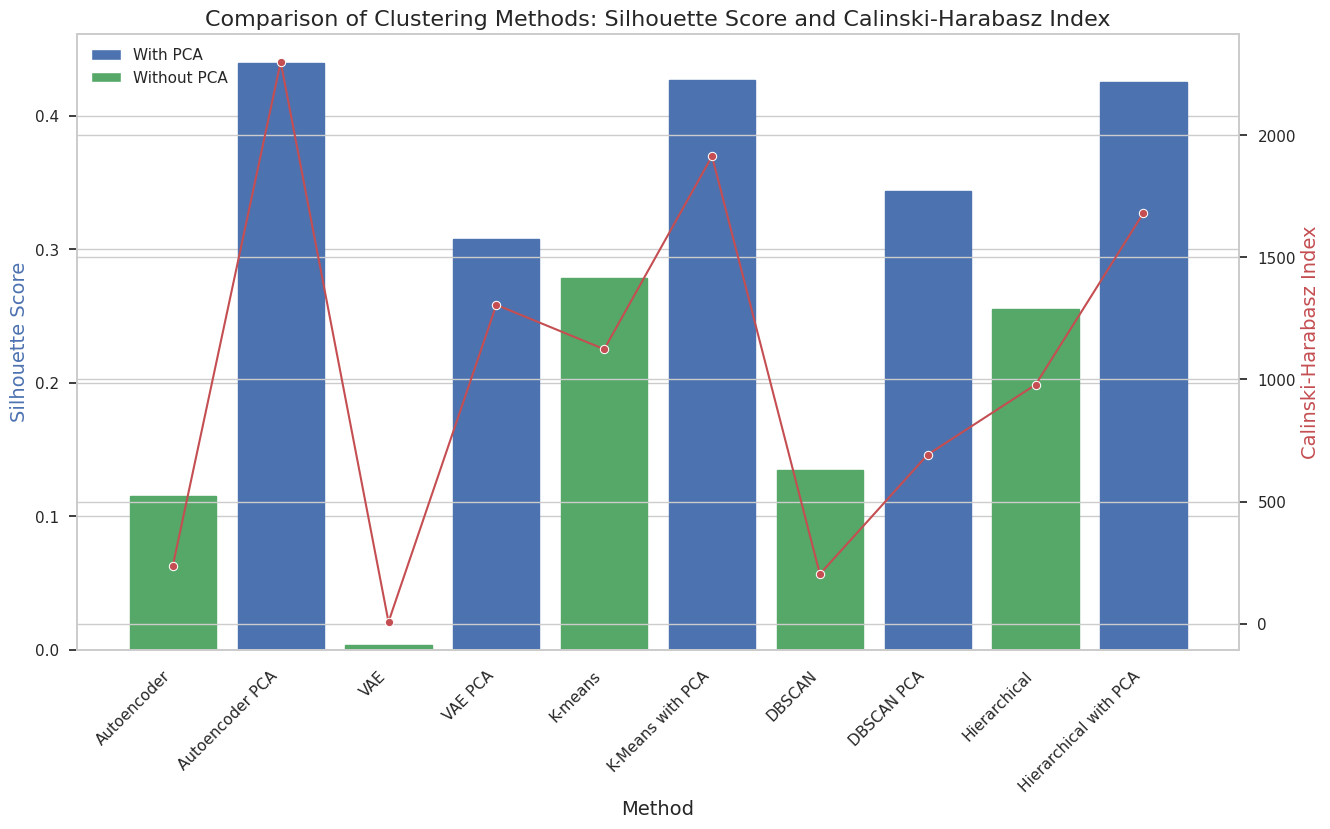

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch

# Updated data
data = {
    'Method': ['Autoencoder', 'Autoencoder PCA', 'VAE', 'VAE PCA', 'K-means', 'K-Means with PCA', 'DBSCAN', 'DBSCAN PCA', 'Hierarchical', 'Hierarchical with PCA'],
    'Silhouette Score': [0.115328, 0.439293, 0.003647, 0.307383, 0.278314, 0.4268, 0.134897, 0.34334, 0.255103, 0.4253],
    'Calinski-Harabasz Index': [238.210063, 2299.436458, 8.008472, 1305.442805, 1123.890273, 1913.4799, 203.678912, 692.4556, 978.564782, 1680.6086]
}

# Create DataFrame
df = pd.DataFrame(data)

# Assign colors based on whether the method name contains 'PCA'
colors = ['b' if 'PCA' in method else 'g' for method in df['Method']]

# Plotting
fig, ax1 = plt.subplots(figsize=(15, 8))

sns.set(style="whitegrid")

# Silhouette Score barplot
bars = sns.barplot(x='Method', y='Silhouette Score', data=df, ax=ax1, palette=colors)

# Add different colors to bars
for bar, color in zip(bars.patches, colors):
    bar.set_color(color)

# Create a second y-axis
ax2 = ax1.twinx()

# Calinski-Harabasz Index lineplot
sns.lineplot(x='Method', y='Calinski-Harabasz Index', data=df, ax=ax2, color='r', marker='o')

# Labels and titles
ax1.set_xlabel('Method', fontsize=14)
ax1.set_ylabel('Silhouette Score', fontsize=14, color='b')
ax2.set_ylabel('Calinski-Harabasz Index', fontsize=14, color='r')

ax1.set_xticklabels(df['Method'], rotation=45, ha='right')

plt.title('Comparison of Clustering Methods: Silhouette Score and Calinski-Harabasz Index', fontsize=16)

# Add legend
legend_elements = [Patch(facecolor='b', label='With PCA'),
                   Patch(facecolor='g', label='Without PCA')]
ax1.legend(handles=legend_elements, loc='upper left')

plt.show()


- **Cluster 0**

1. Low Spent and Low Income
1. Majority of these are parent
1. At the max 5 memebrs in the family

- **Cluster 1**

1. Average Spent & Average Income
1. Definitely a parent
1. At the max 4 memebrs in the family

- **Cluster 2**

1. High Spent and High Income
1. Definitely not a parent
1. At the max 2 memebrs in the family

- **Cluster 3**

1. High Spent and Average Income
1. Definitely not a parent
1. At the max 3 memebrs in the family
